# LG전자 실적발표 워드클라우드 분석

## 📋 분석 개요
- **목적**: LG전자 분기별 실적발표 자료에서 핵심 키워드 추출 및 시각화
- **데이터**: 2024년 1Q~4Q 실적발표 PDF 파일
- **방법**: PDF 텍스트 추출 → 토큰화 → DataFrame → XML → 워드클라우드

## 📂 분석 대상 파일
1. `2024.4Q Earning Release of LGE_Transcript_KR.pdf`
2. `2024년 2분기 LG전자 경영실적 발표 컨퍼런스콜 전문_20240725.pdf`
3. `2024년 3분기 LG전자 경영실적 발표 컨퍼런스콜 전문_20241024.pdf`
4. `LG전자 2024년 1분기 기업설명회 실적 PT.pdf`

In [38]:
# 필요한 라이브러리 설치 (최초 1회만 실행)
# !pip install PyPDF2 pdfplumber wordcloud konlpy matplotlib seaborn pandas numpy lxml beautifulsoup4

In [51]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import xml.etree.ElementTree as ET
from xml.dom import minidom
import warnings
warnings.filterwarnings('ignore')

# PDF 처리
import PyPDF2
import pdfplumber

# 자연어 처리
from konlpy.tag import Okt, Mecab, Kkma
from collections import Counter

# 워드클라우드
from wordcloud import WordCloud

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 로딩 완료!")

✅ 라이브러리 로딩 완료!


In [52]:
# PDF 파일 경로 설정
pdf_files = {
    '2024_1Q': 'LG전자 2024년 1분기 기업설명회 실적 PT.pdf',
    '2024_2Q': '2024년 2분기 LG전자 경영실적 발표 컨퍼런스콜 전문_20240725.pdf',
    '2024_3Q': '2024년 3분기 LG전자 경영실적 발표 컨퍼런스콜 전문_20241024.pdf',
    '2024_4Q': '2024.4Q Earning Release of LGE_Transcript_KR.pdf'
}

# 현재 디렉토리 확인
current_dir = Path('.')
print(f"현재 작업 디렉토리: {current_dir.absolute()}")

# 파일 존재 여부 확인
existing_files = {}
for quarter, filename in pdf_files.items():
    file_path = current_dir / filename
    if file_path.exists():
        existing_files[quarter] = file_path
        print(f"✅ {quarter}: {filename}")
    else:
        print(f"❌ {quarter}: {filename} - 파일을 찾을 수 없습니다.")

print(f"\n📊 분석 가능한 파일 수: {len(existing_files)}개")

현재 작업 디렉토리: c:\Users\lgdx\LG_DX_School\02_DX_Methodology\1_Business_Experience_BX
✅ 2024_1Q: LG전자 2024년 1분기 기업설명회 실적 PT.pdf
✅ 2024_2Q: 2024년 2분기 LG전자 경영실적 발표 컨퍼런스콜 전문_20240725.pdf
✅ 2024_3Q: 2024년 3분기 LG전자 경영실적 발표 컨퍼런스콜 전문_20241024.pdf
✅ 2024_4Q: 2024.4Q Earning Release of LGE_Transcript_KR.pdf

📊 분석 가능한 파일 수: 4개


In [54]:
def extract_text_from_pdf(file_path):
    """
    PDF 파일에서 텍스트 추출
    pdfplumber와 PyPDF2를 모두 시도하여 최대한 많은 텍스트 추출
    """
    text = ""
    
    # Method 1: pdfplumber 시도
    try:
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        print(f"✅ pdfplumber로 텍스트 추출 성공: {len(text)}자")
    except Exception as e:
        print(f"❌ pdfplumber 실패: {e}")
    
    # Method 2: PyPDF2로 추가 시도 (텍스트가 적을 경우)
    if len(text) < 1000:
        try:
            with open(file_path, 'rb') as file:
                pdf_reader = PyPDF2.PdfReader(file)
                additional_text = ""
                for page in pdf_reader.pages:
                    page_text = page.extract_text()
                    if page_text:
                        additional_text += page_text + "\n"
                
                if len(additional_text) > len(text):
                    text = additional_text
                    print(f"✅ PyPDF2로 더 많은 텍스트 추출: {len(text)}자")
        except Exception as e:
            print(f"❌ PyPDF2 실패: {e}")
    
    return text

# 모든 PDF 파일에서 텍스트 추출
extracted_texts = {}

for quarter, file_path in existing_files.items():
    print(f"\n📄 {quarter} 파일 처리 중...")
    text = extract_text_from_pdf(file_path)
    
    if text.strip():
        extracted_texts[quarter] = text
        print(f"📊 추출된 텍스트 길이: {len(text):,}자")
        print(f"📝 미리보기: {text[:200]}...")
    else:
        print("❌ 텍스트 추출 실패")

print(f"\n🎉 총 {len(extracted_texts)}개 파일에서 텍스트 추출 완료!")


📄 2024_1Q 파일 처리 중...


Cannot set gray non-stroke color because /'P180' is an invalid float value
Cannot set gray non-stroke color because /'P184' is an invalid float value
Cannot set gray non-stroke color because /'P188' is an invalid float value
Cannot set gray non-stroke color because /'P184' is an invalid float value
Cannot set gray non-stroke color because /'P188' is an invalid float value
Cannot set gray non-stroke color because /'P192' is an invalid float value
Cannot set gray non-stroke color because /'P196' is an invalid float value
Cannot set gray non-stroke color because /'P200' is an invalid float value
Cannot set gray non-stroke color because /'P204' is an invalid float value
Cannot set gray non-stroke color because /'P192' is an invalid float value
Cannot set gray non-stroke color because /'P196' is an invalid float value
Cannot set gray non-stroke color because /'P200' is an invalid float value
Cannot set gray non-stroke color because /'P204' is an invalid float value
Cannot set gray non-strok

✅ pdfplumber로 텍스트 추출 성공: 10761자
📊 추출된 텍스트 길이: 10,761자
📝 미리보기: 2024년 1분기 실적 발표
2024년 4월 25일
LG전자
본자료에포함된2024년 1분기LG전자(이하“회사”)의경영실적및재무성과와관련한모든정보는
한국채택국제회계기준에따라작성되었습니다.
2024년 1분기회사의경영실적및재무성과는투자자의편의를위해외부감사인의검토절차가완료되지
않은상태에서조기에작성된것으로그내용중일부는외부감사인의검토과정에서달라질수있습니다.
한편본자료...

📄 2024_2Q 파일 처리 중...
✅ pdfplumber로 텍스트 추출 성공: 14492자
📊 추출된 텍스트 길이: 14,492자
📝 미리보기: <LG전자 2024년 2분기 경영실적 발표 컨퍼런스콜>
• 일시 : 2024. 7. 25. 오후4 시
○ 사회자
안녕하십니까? LG전자 실적 발표 컨퍼런스콜에 참여해 주셔서 감사합니다.
오늘 진행순서는 LG전자의 발표 후 참석해 주신 여러분과 질의응답 시간을 가
질 예정입니다.
질문을 하실 분은 전화기 버튼의 별표와 1번을 누르시기 바랍니다.
참고로 경영성...

📄 2024_3Q 파일 처리 중...
✅ pdfplumber로 텍스트 추출 성공: 14492자
📊 추출된 텍스트 길이: 14,492자
📝 미리보기: <LG전자 2024년 2분기 경영실적 발표 컨퍼런스콜>
• 일시 : 2024. 7. 25. 오후4 시
○ 사회자
안녕하십니까? LG전자 실적 발표 컨퍼런스콜에 참여해 주셔서 감사합니다.
오늘 진행순서는 LG전자의 발표 후 참석해 주신 여러분과 질의응답 시간을 가
질 예정입니다.
질문을 하실 분은 전화기 버튼의 별표와 1번을 누르시기 바랍니다.
참고로 경영성...

📄 2024_3Q 파일 처리 중...
✅ pdfplumber로 텍스트 추출 성공: 14727자
📊 추출된 텍스트 길이: 14,727자
📝 미리보기: <LG전자 2024년 3분기 실적발표 컨퍼런스콜>
• 일시: 2024. 10. 24. 오후4시 30분
○ 사회자
안녕하십니까? LG전

In [83]:
# 텍스트 전처리 함수
def preprocess_text(text):
    """
    텍스트 전처리: 특수문자 제거, 공백 정리
    """
    # 특수문자 및 숫자 제거 (한글, 영문, 공백만 유지)
    text = re.sub(r'[^가-힣a-zA-Z\s]', ' ', text)
    
    # 연속된 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
    
    # 앞뒤 공백 제거
    text = text.strip()
    
    return text

# 형태소 분석기 초기화
try:
    morphAnalyzer = Okt()  # Open Korean Text
    print("✅ Okt 형태소 분석기 로딩 완료")
except:
    try:
        morphAnalyzer = Kkma()  # 꼬꼬마
        print("✅ Kkma 형태소 분석기 로딩 완료")
    except:
        print("❌ 형태소 분석기 로딩 실패")
        morphAnalyzer = None

def tokenize_text(text, quarter_name):
    """
    텍스트를 토큰화하여 의미있는 단어들 추출
    """
    print(f"🔍 {quarter_name} 토큰화 시작...")
    
    # 텍스트 전처리
    cleaned_text = preprocess_text(text)
    
    if morphAnalyzer is None:
        # 형태소 분석기가 없을 경우 간단한 단어 분리
        tokens = cleaned_text.split()
        tokens = [token for token in tokens if len(token) > 1]
    else:
        # 형태소 분석으로 명사 추출
        tokens = morphAnalyzer.pos(cleaned_text)
        
        # 의미있는 품사만 선택 (명사, 외국어)
        meaningful_pos = ['Noun',  'Foreign']
        tokens = [word for word, pos in tokens 
                 if pos in meaningful_pos and len(word) > 1]
    
    # 불용어 제거 (일반적인 단어들)
    stopwords = {
        '것', '수', '등', '및', '또한', '하는', '있는', '되는', '같은', '많은', 
        '이런', '그런', '저런', '어떤', '이것', '그것', '저것', '여기', '거기', 
        '저기', '때문', '위해', '통해', '대해', '관련', '경우', '상황', '문제',
        '부분', '측면', '방법', '방식', '과정', '결과', '효과', '영향', '변화',
        '내용', '정보', '자료', '데이터', '시간', '기간', '년도', '월', '일',
        '오늘', '어제', '내일', '지금', '현재', '앞으로', '이전', '다음',
        '첫째', '둘째', '셋째', '마지막', '전체', '일부', '대부분', '모든', '분기',
        '대비', '상무', '것으로', '전년', '수요', '당사는', '말씀을', '대해서', '동기',
        '질문', '그리고', '박원재', '이어서', '이상입니다', '전망에', '따른', '분은', '다음으로',
    # 추가 불용어 (기업 문서용)
        '있습니다', '합니다', '입니다', '됩니다', '했습니다', '하겠습니다',
        '드립니다', '말씀', '드리겠습니다', '감사합니다', '안녕하십니까'


    }
    
    # 불용어 및 짧은 단어 제거
    filtered_tokens = [token for token in tokens 
                      if token not in stopwords and len(token) > 1]
    
    print(f"📊 {quarter_name} 토큰 수: {len(filtered_tokens):,}개")
    
    return filtered_tokens

# 모든 텍스트 토큰화
all_tokens = {}
combined_tokens = []

for quarter, text in extracted_texts.items():
    tokens = tokenize_text(text, quarter)
    all_tokens[quarter] = tokens
    combined_tokens.extend(tokens)

print(f"\n🎯 전체 토큰 수: {len(combined_tokens):,}개")

❌ 형태소 분석기 로딩 실패
🔍 2024_1Q 토큰화 시작...
📊 2024_1Q 토큰 수: 696개
🔍 2024_2Q 토큰화 시작...
📊 2024_2Q 토큰 수: 2,600개
🔍 2024_3Q 토큰화 시작...
📊 2024_3Q 토큰 수: 2,610개
🔍 2024_4Q 토큰화 시작...
📊 2024_4Q 토큰 수: 2,912개

🎯 전체 토큰 수: 8,818개


In [85]:
# 토큰 빈도 분석 및 DataFrame 생성
def create_token_dataframe(tokens_dict):
    """
    토큰들을 분석하여 DataFrame 생성
    """
    # 전체 토큰 빈도 계산
    all_tokens_flat = []
    for tokens in tokens_dict.values():
        all_tokens_flat.extend(tokens)
    
    token_counts = Counter(all_tokens_flat)
    
    # 분기별 빈도 계산
    quarter_counts = {}
    for quarter, tokens in tokens_dict.items():
        quarter_counts[quarter] = Counter(tokens)
    
    # DataFrame 생성
    df_data = []
    
    for token, total_count in token_counts.most_common():
        row = {
            'token': token,
            'total_frequency': total_count,
            'total_percentage': (total_count / len(all_tokens_flat)) * 100
        }
        
        # 각 분기별 빈도 추가
        for quarter in tokens_dict.keys():
            quarter_freq = quarter_counts[quarter].get(token, 0)
            row[f'{quarter}_frequency'] = quarter_freq
            
            # 해당 분기 전체 토큰 대비 비율
            quarter_total = len(tokens_dict[quarter])
            row[f'{quarter}_percentage'] = (quarter_freq / quarter_total * 100) if quarter_total > 0 else 0
        
        df_data.append(row)
    
    df = pd.DataFrame(df_data)
    
    return df

# DataFrame 생성
print("📊 토큰 DataFrame 생성 중...")
token_df = create_token_dataframe(all_tokens)

print(f"✅ DataFrame 생성 완료!")
print(f"📏 DataFrame 크기: {token_df.shape}")
print(f"📋 컬럼: {list(token_df.columns)}")

# 상위 20개 토큰 미리보기
print("\n📈 상위 20개 빈도 토큰:")
display(token_df.head(20)[['token', 'total_frequency', 'total_percentage']])

📊 토큰 DataFrame 생성 중...
✅ DataFrame 생성 완료!
📏 DataFrame 크기: (3855, 11)
📋 컬럼: ['token', 'total_frequency', 'total_percentage', '2024_1Q_frequency', '2024_1Q_percentage', '2024_2Q_frequency', '2024_2Q_percentage', '2024_3Q_frequency', '2024_3Q_percentage', '2024_4Q_frequency', '2024_4Q_percentage']

📈 상위 20개 빈도 토큰:


,token,total_frequency,total_percentage
0,매출,88,0.997959
1,시장,64,0.725788
2,사업,54,0.612384
3,전기차,42,0.476298
4,제품,37,0.419596
5,영업이익,34,0.385575
6,실적,32,0.362894
7,LG전자,30,0.340213
8,주요,27,0.306192
9,글로벌,27,0.306192


In [79]:
# DataFrame을 XML로 저장
def save_dataframe_to_xml(df, filename='lg_electronics_token_analysis.xml'):
    """
    DataFrame을 XML 형태로 저장
    """
    print(f"💾 XML 파일 생성 중: {filename}")
    
    # Root element 생성
    root = ET.Element('lg_electronics_token_analysis')
    
    # 메타데이터 추가
    metadata = ET.SubElement(root, 'metadata')
    ET.SubElement(metadata, 'generation_date').text = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    ET.SubElement(metadata, 'total_tokens').text = str(len(df))
    ET.SubElement(metadata, 'analyzed_quarters').text = ', '.join([col.split('_')[0] for col in df.columns if '_frequency' in col])
    
    # 토큰 데이터 추가
    tokens_element = ET.SubElement(root, 'tokens')
    
    for _, row in df.iterrows():
        token_element = ET.SubElement(tokens_element, 'token')
        
        # 기본 정보
        ET.SubElement(token_element, 'word').text = str(row['token'])
        ET.SubElement(token_element, 'total_frequency').text = str(row['total_frequency'])
        ET.SubElement(token_element, 'total_percentage').text = f"{row['total_percentage']:.4f}"
        
        # 분기별 정보
        quarterly_data = ET.SubElement(token_element, 'quarterly_data')
        
        for col in df.columns:
            if '_frequency' in col:
                quarter = col.split('_')[0]
                quarter_element = ET.SubElement(quarterly_data, 'quarter', attrib={'name': quarter})
                ET.SubElement(quarter_element, 'frequency').text = str(row[col])
                
                # 해당 분기의 percentage 컬럼 찾기
                percentage_col = f'{quarter}_percentage'
                if percentage_col in df.columns:
                    ET.SubElement(quarter_element, 'percentage').text = f"{row[percentage_col]:.4f}"
    
    # XML을 보기 좋게 포맷팅
    rough_string = ET.tostring(root, 'utf-8')
    reparsed = minidom.parseString(rough_string)
    
    # 파일 저장
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(reparsed.toprettyxml(indent="  ", encoding=None))
    
    print(f"✅ XML 파일 저장 완료: {filename}")
    print(f"📁 파일 크기: {Path(filename).stat().st_size / 1024:.2f} KB")
    
    return filename

# XML 파일 생성
xml_filename = save_dataframe_to_xml(token_df)

# XML 파일 일부 내용 미리보기
print("\n📄 XML 파일 미리보기 (처음 20줄):")
with open(xml_filename, 'r', encoding='utf-8') as f:
    lines = f.readlines()[:20]
    for i, line in enumerate(lines, 1):
        print(f"{i:2d}: {line.rstrip()}")

💾 XML 파일 생성 중: lg_electronics_token_analysis.xml
✅ XML 파일 저장 완료: lg_electronics_token_analysis.xml
📁 파일 크기: 2575.72 KB

📄 XML 파일 미리보기 (처음 20줄):
 1: <?xml version="1.0" ?>
 2: <lg_electronics_token_analysis>
 3:   <metadata>
 4:     <generation_date>2025-07-30 15:14:43</generation_date>
 5:     <total_tokens>3862</total_tokens>
 6:     <analyzed_quarters>total, 2024, 2024, 2024, 2024</analyzed_quarters>
 7:   </metadata>
 8:   <tokens>
 9:     <token>
10:       <word>매출</word>
11:       <total_frequency>88</total_frequency>
12:       <total_percentage>0.9764</total_percentage>
13:       <quarterly_data>
14:         <quarter name="total">
15:           <frequency>88</frequency>
16:           <percentage>0.9764</percentage>
17:         </quarter>
18:         <quarter name="2024">
19:           <frequency>8</frequency>
20:         </quarter>


☁️ 워드클라우드 생성 중... (상위 100개 단어)


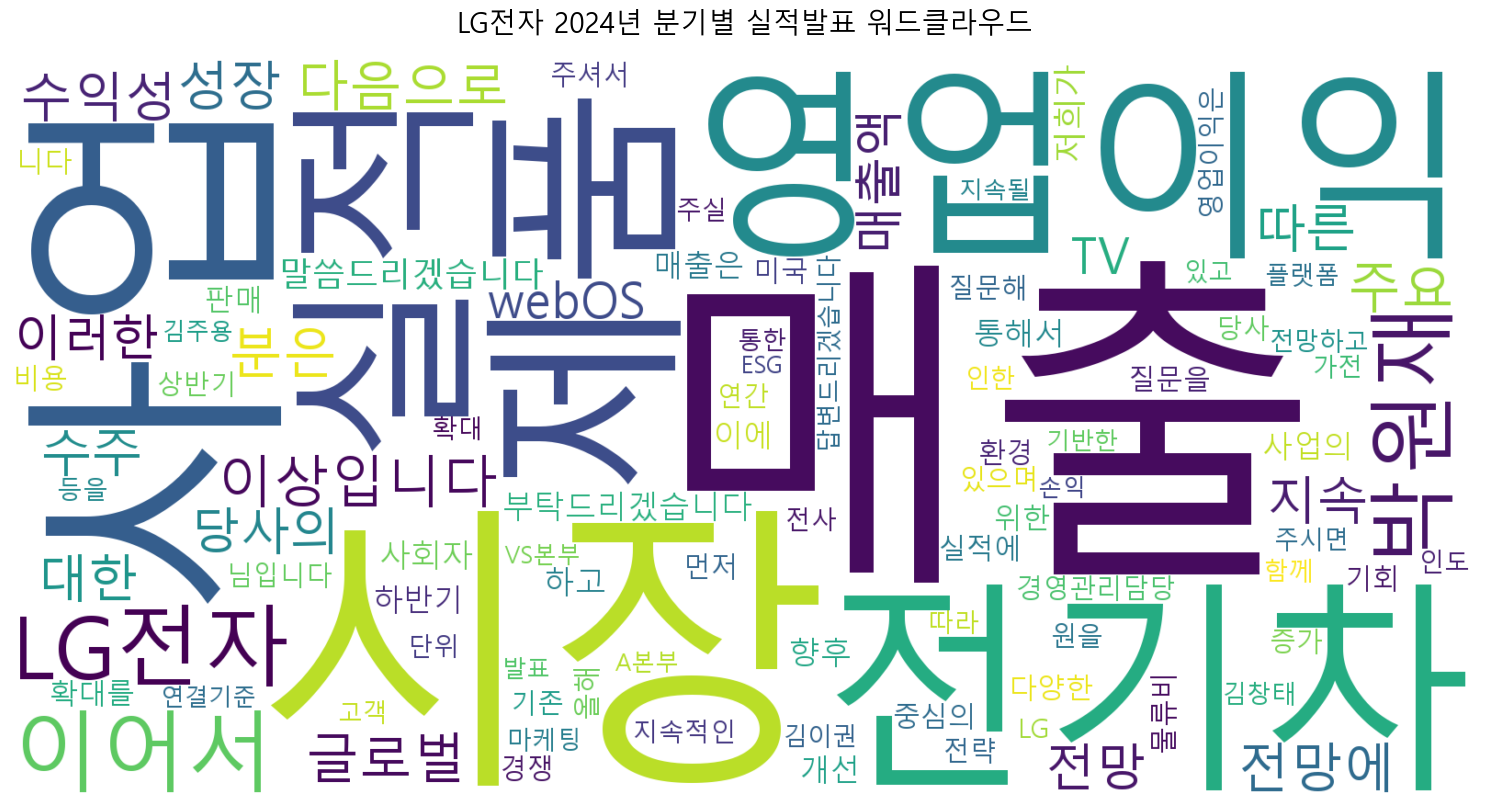

✅ 전체 워드클라우드 생성 완료!


In [80]:
# 워드클라우드 생성
def create_wordcloud(token_df, top_n=100, figsize=(15, 10)):
    """
    토큰 DataFrame을 이용하여 워드클라우드 생성
    """
    print(f"☁️ 워드클라우드 생성 중... (상위 {top_n}개 단어)")
    
    # 상위 N개 토큰 선택
    top_tokens = token_df.head(top_n)
    
    # 빈도수를 딕셔너리로 변환
    word_freq = dict(zip(top_tokens['token'], top_tokens['total_frequency']))
    
    # 워드클라우드 객체 생성
    wordcloud = WordCloud(
        width=1600,
        height=800,
        background_color='white',
        max_words=top_n,
        colormap='viridis',
        font_path='C:/Windows/Fonts/malgun.ttf',  # Windows 한글 폰트
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_freq)
    
    # 전체 워드클라우드 그리기
    plt.figure(figsize=figsize)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('LG전자 2024년 분기별 실적발표 워드클라우드', fontsize=20, pad=20)
    plt.tight_layout()
    
    # 이미지 저장
    plt.savefig('lg_electronics_wordcloud_overall.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return wordcloud

# 전체 워드클라우드 생성
wordcloud_overall = create_wordcloud(token_df)

print("✅ 전체 워드클라우드 생성 완료!")

📊 분기별 워드클라우드 생성 중...


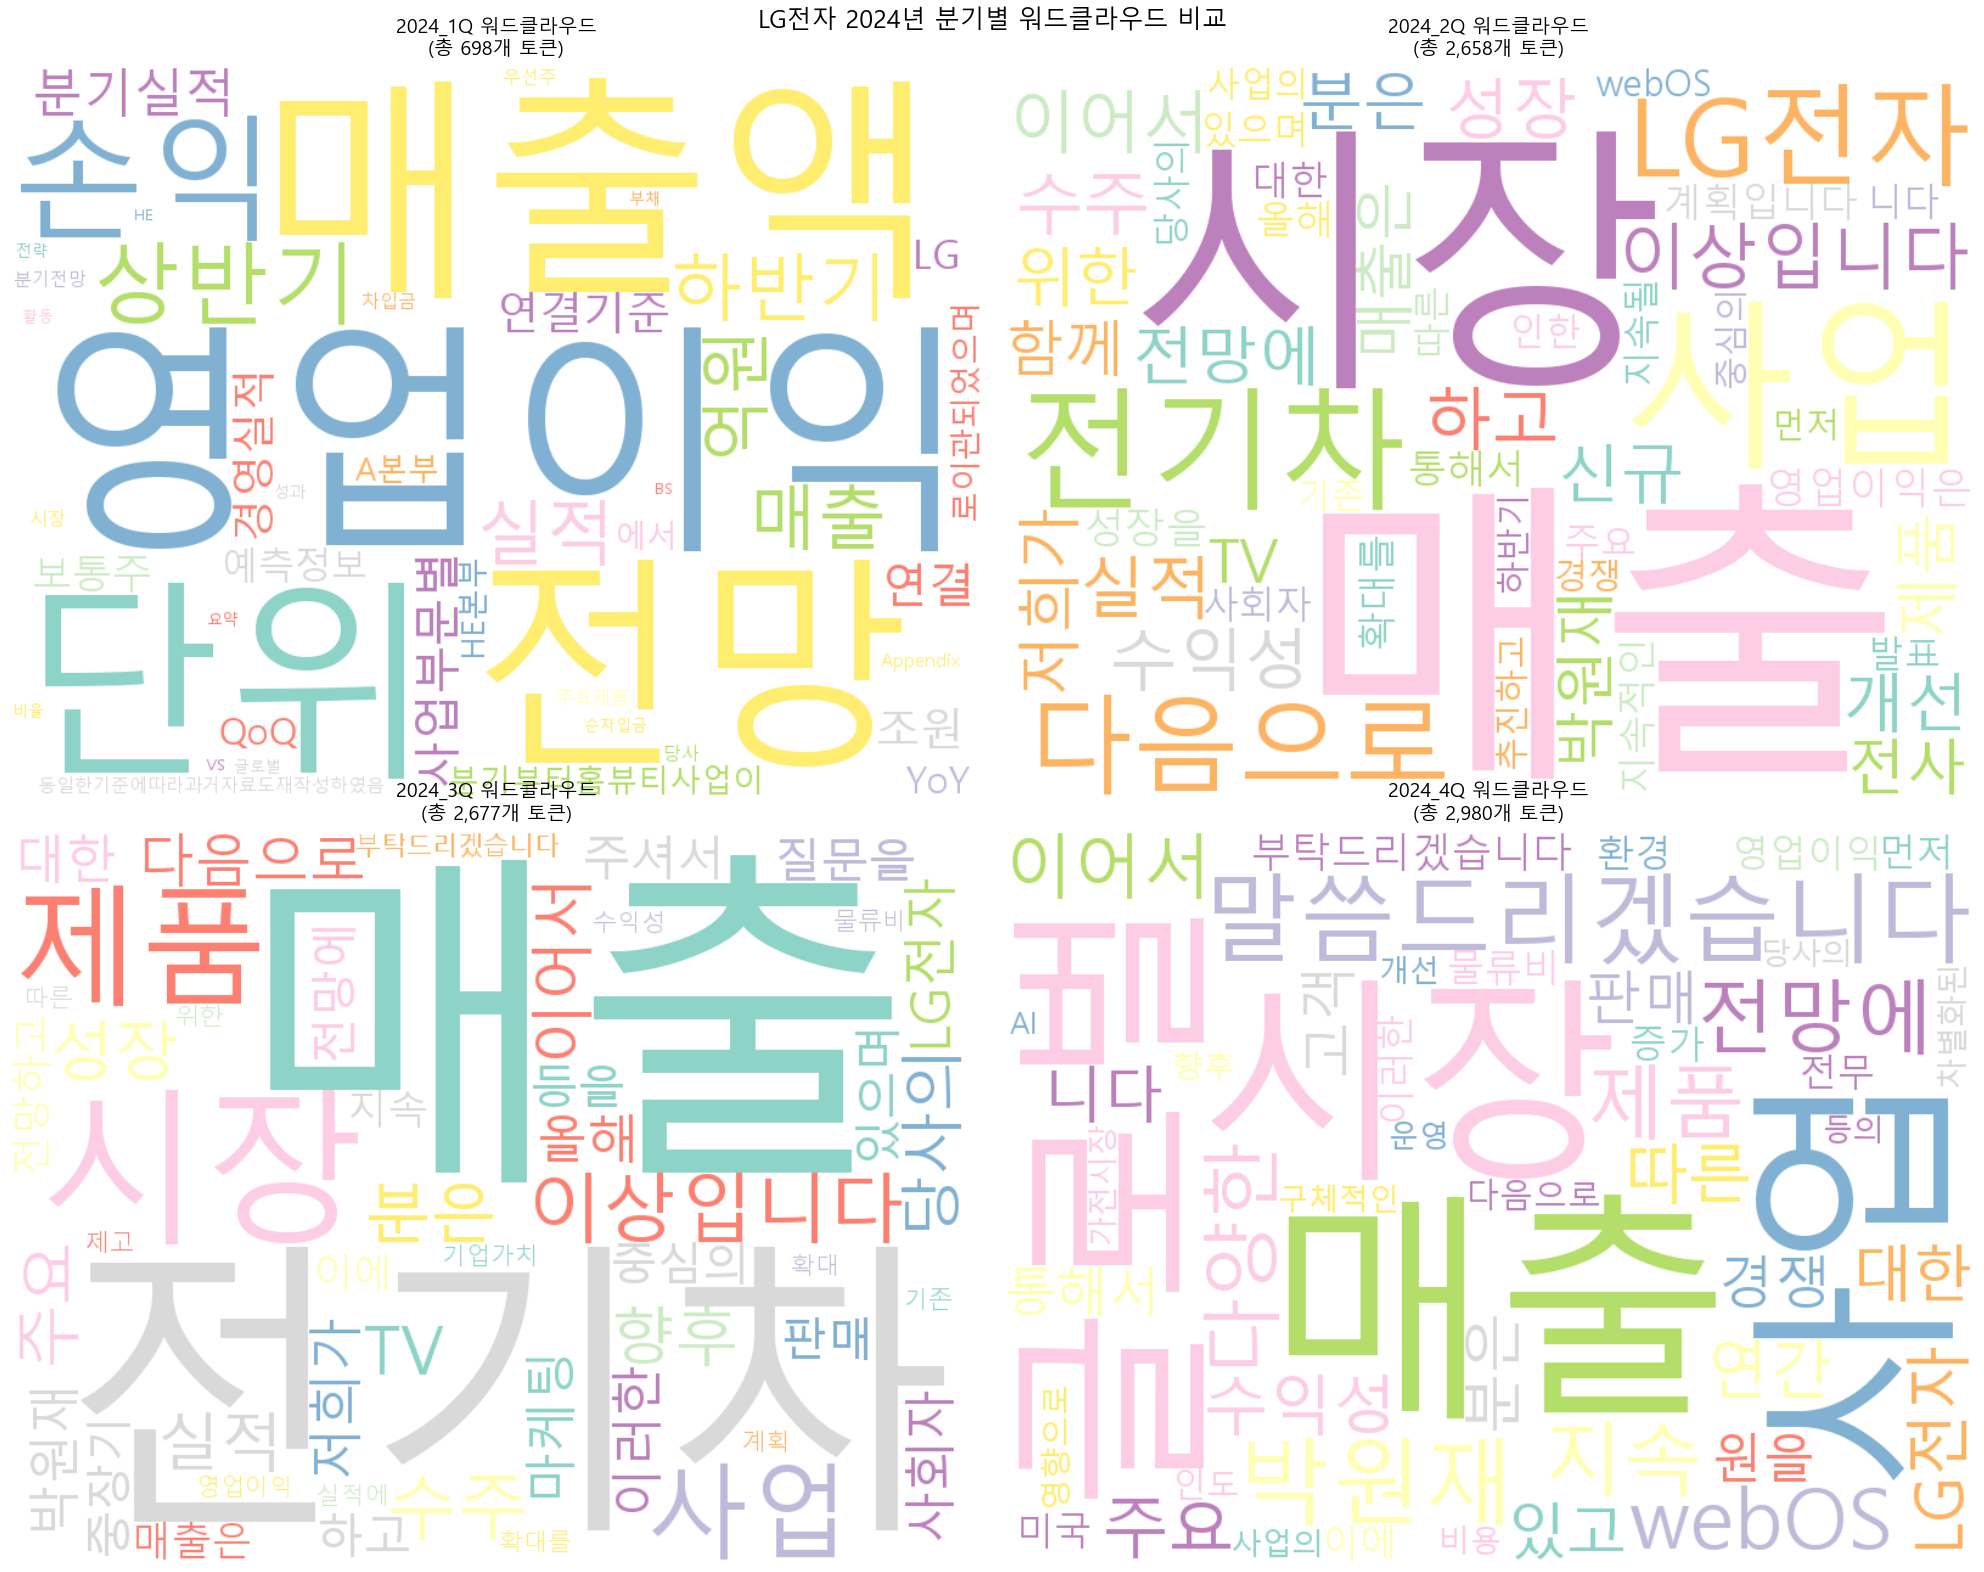

✅ 분기별 워드클라우드 생성 완료!


In [81]:
# 분기별 워드클라우드 생성
def create_quarterly_wordclouds(tokens_dict, top_n=50):
    """
    분기별로 개별 워드클라우드 생성
    """
    print("📊 분기별 워드클라우드 생성 중...")
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    quarters = list(tokens_dict.keys())
    
    for i, quarter in enumerate(quarters):
        if i >= 4:  # 최대 4개 분기만
            break
            
        # 해당 분기 토큰 빈도 계산
        quarter_tokens = tokens_dict[quarter]
        quarter_freq = Counter(quarter_tokens)
        
        # 상위 N개 선택
        top_quarter_tokens = dict(quarter_freq.most_common(top_n))
        
        if top_quarter_tokens:  # 토큰이 있을 경우에만
            # 워드클라우드 생성
            wordcloud = WordCloud(
                width=800,
                height=600,
                background_color='white',
                max_words=top_n,
                colormap='Set3',
                font_path='C:/Windows/Fonts/malgun.ttf',
                relative_scaling=0.5,
                min_font_size=8
            ).generate_from_frequencies(top_quarter_tokens)
            
            # 서브플롯에 그리기
            axes[i].imshow(wordcloud, interpolation='bilinear')
            axes[i].axis('off')
            axes[i].set_title(f'{quarter} 워드클라우드\n(총 {len(quarter_tokens):,}개 토큰)', 
                            fontsize=14, pad=10)
        else:
            axes[i].text(0.5, 0.5, f'{quarter}\n데이터 없음', 
                        ha='center', va='center', fontsize=16)
            axes[i].axis('off')
    
    # 빈 서브플롯 숨기기
    for j in range(len(quarters), 4):
        axes[j].axis('off')
    
    plt.suptitle('LG전자 2024년 분기별 워드클라우드 비교', fontsize=18, y=0.98)
    plt.tight_layout()
    
    # 이미지 저장
    plt.savefig('lg_electronics_wordcloud_quarterly.png', dpi=300, bbox_inches='tight')
    plt.show()

# 분기별 워드클라우드 생성
create_quarterly_wordclouds(all_tokens)

print("✅ 분기별 워드클라우드 생성 완료!")

📈 상위 15개 키워드 트렌드 분석


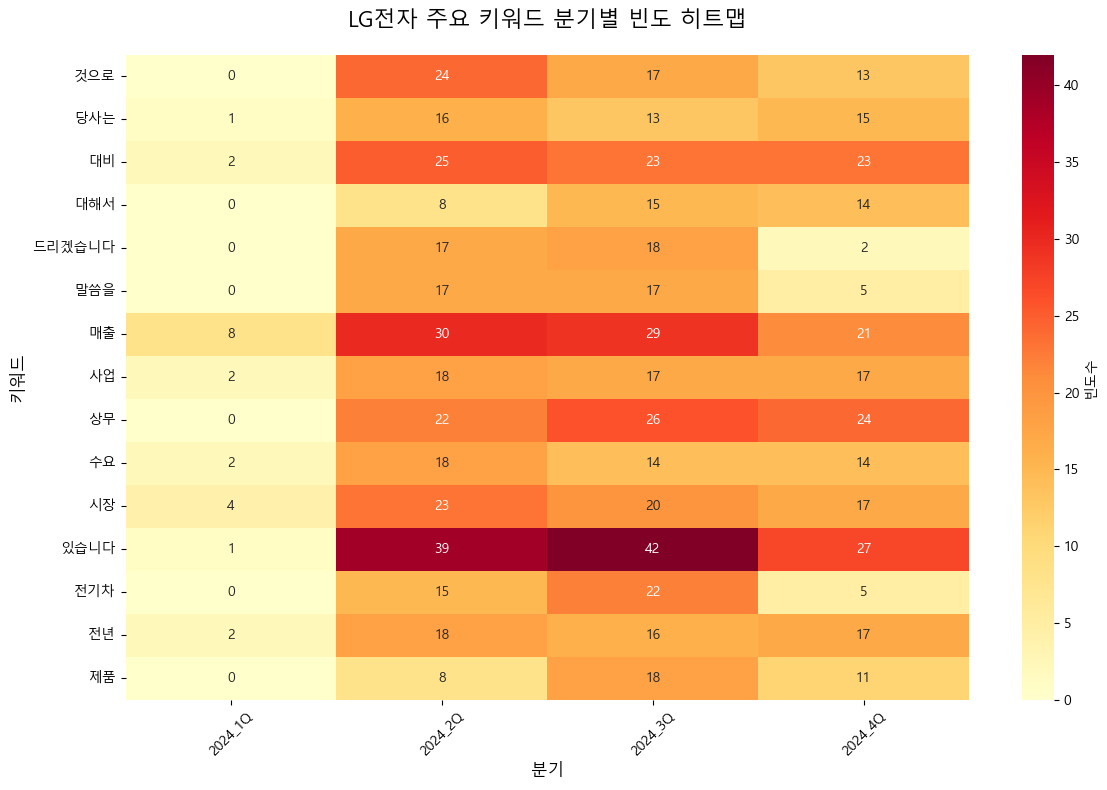

✅ 키워드 트렌드 분석 완료!


In [47]:
# 주요 키워드 트렌드 분석
def analyze_keyword_trends(token_df, top_keywords=15):
    """
    주요 키워드들의 분기별 트렌드 분석
    """
    print(f"📈 상위 {top_keywords}개 키워드 트렌드 분석")
    
    # 상위 키워드 선택
    top_tokens = token_df.head(top_keywords)['token'].tolist()
    
    # 분기별 빈도 데이터 추출 (올바른 컬럼명 사용)
    quarters = ['2024_1Q', '2024_2Q', '2024_3Q', '2024_4Q']
    
    # 트렌드 시각화를 위한 데이터 준비
    trend_data = []
    
    for token in top_tokens:
        token_row = token_df[token_df['token'] == token].iloc[0]
        for quarter in quarters:
            frequency = token_row[f'{quarter}_frequency']
            percentage = token_row[f'{quarter}_percentage']
            
            trend_data.append({
                'token': token,
                'quarter': quarter,
                'frequency': frequency,
                'percentage': percentage
            })
    
    trend_df = pd.DataFrame(trend_data)
    
    # 히트맵으로 키워드 트렌드 시각화
    plt.figure(figsize=(12, 8))
    
    # 피벗 테이블 생성 (빈도 기준)
    pivot_freq = trend_df.pivot(index='token', columns='quarter', values='frequency')
    
    # 히트맵 그리기
    sns.heatmap(pivot_freq, annot=True, fmt='d', cmap='YlOrRd', 
                cbar_kws={'label': '빈도수'})
    
    plt.title('LG전자 주요 키워드 분기별 빈도 히트맵', fontsize=16, pad=20)
    plt.xlabel('분기', fontsize=12)
    plt.ylabel('키워드', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # 이미지 저장
    plt.savefig('lg_electronics_keyword_trends.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return trend_df

# 키워드 트렌드 분석
trend_analysis = analyze_keyword_trends(token_df)

print("✅ 키워드 트렌드 분석 완료!")

In [48]:
# 분석 결과 요약
def generate_analysis_summary(token_df, extracted_texts, trend_df):
    """
    분석 결과 종합 요약 생성
    """
    print("📋 분석 결과 요약 생성 중...")
    
    summary = {
        '분석_일시': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        '분석_파일_수': len(extracted_texts),
        '전체_고유_토큰_수': len(token_df),
        '전체_토큰_수': token_df['total_frequency'].sum(),
        '상위_10개_키워드': token_df.head(10)['token'].tolist(),
        '분기별_문서_길이': {quarter: len(text) for quarter, text in extracted_texts.items()},
        '분기별_토큰_수': {quarter: trend_df[trend_df['quarter'] == quarter]['frequency'].sum() 
                      for quarter in trend_df['quarter'].unique()}
    }
    
    print("\n" + "="*60)
    print("🎯 LG전자 실적발표 워드클라우드 분석 결과 요약")
    print("="*60)
    
    print(f"📅 분석 일시: {summary['분석_일시']}")
    print(f"📄 분석 파일 수: {summary['분석_파일_수']}개")
    print(f"🔤 전체 고유 토큰 수: {summary['전체_고유_토큰_수']:,}개")
    print(f"📊 전체 토큰 수: {summary['전체_토큰_수']:,}개")
    
    print("\n🏆 상위 10개 핵심 키워드:")
    for i, keyword in enumerate(summary['상위_10개_키워드'], 1):
        frequency = token_df[token_df['token'] == keyword]['total_frequency'].iloc[0]
        percentage = token_df[token_df['token'] == keyword]['total_percentage'].iloc[0]
        print(f"  {i:2d}. {keyword:12s} - {frequency:4d}회 ({percentage:.2f}%)")
    
    print("\n📈 분기별 분석 현황:")
    for quarter in summary['분기별_문서_길이'].keys():
        doc_length = summary['분기별_문서_길이'][quarter]
        token_count = summary['분기별_토큰_수'].get(quarter, 0)
        print(f"  📋 {quarter}: 문서 길이 {doc_length:,}자, 토큰 {token_count:,}개")
    
    print("\n💾 생성된 파일:")
    print("  📊 lg_electronics_token_analysis.xml - 토큰 분석 데이터")
    print("  ☁️ lg_electronics_wordcloud_overall.png - 전체 워드클라우드")
    print("  📅 lg_electronics_wordcloud_quarterly.png - 분기별 워드클라우드")
    print("  📈 lg_electronics_keyword_trends.png - 키워드 트렌드 분석")
    
    print("\n✅ 분석 완료!")
    print("="*60)
    
    return summary

# 최종 요약 생성
final_summary = generate_analysis_summary(token_df, extracted_texts, trend_analysis)

📋 분석 결과 요약 생성 중...

🎯 LG전자 실적발표 워드클라우드 분석 결과 요약
📅 분석 일시: 2025-07-30 12:38:01
📄 분석 파일 수: 4개
🔤 전체 고유 토큰 수: 3,884개
📊 전체 토큰 수: 9,772개

🏆 상위 10개 핵심 키워드:
   1. 있습니다         -  109회 (1.12%)
   2. 매출           -   88회 (0.90%)
   3. 대비           -   73회 (0.75%)
   4. 상무           -   72회 (0.74%)
   5. 시장           -   64회 (0.65%)
   6. 사업           -   54회 (0.55%)
   7. 것으로          -   54회 (0.55%)
   8. 전년           -   53회 (0.54%)
   9. 수요           -   48회 (0.49%)
  10. 당사는          -   45회 (0.46%)

📈 분기별 분석 현황:
  📋 2024_1Q: 문서 길이 10,761자, 토큰 22개
  📋 2024_2Q: 문서 길이 14,492자, 토큰 298개
  📋 2024_3Q: 문서 길이 14,727자, 토큰 307개
  📋 2024_4Q: 문서 길이 15,889자, 토큰 225개

💾 생성된 파일:
  📊 lg_electronics_token_analysis.xml - 토큰 분석 데이터
  ☁️ lg_electronics_wordcloud_overall.png - 전체 워드클라우드
  📅 lg_electronics_wordcloud_quarterly.png - 분기별 워드클라우드
  📈 lg_electronics_keyword_trends.png - 키워드 트렌드 분석

✅ 분석 완료!


🔍 토큰 특성 분석 중...


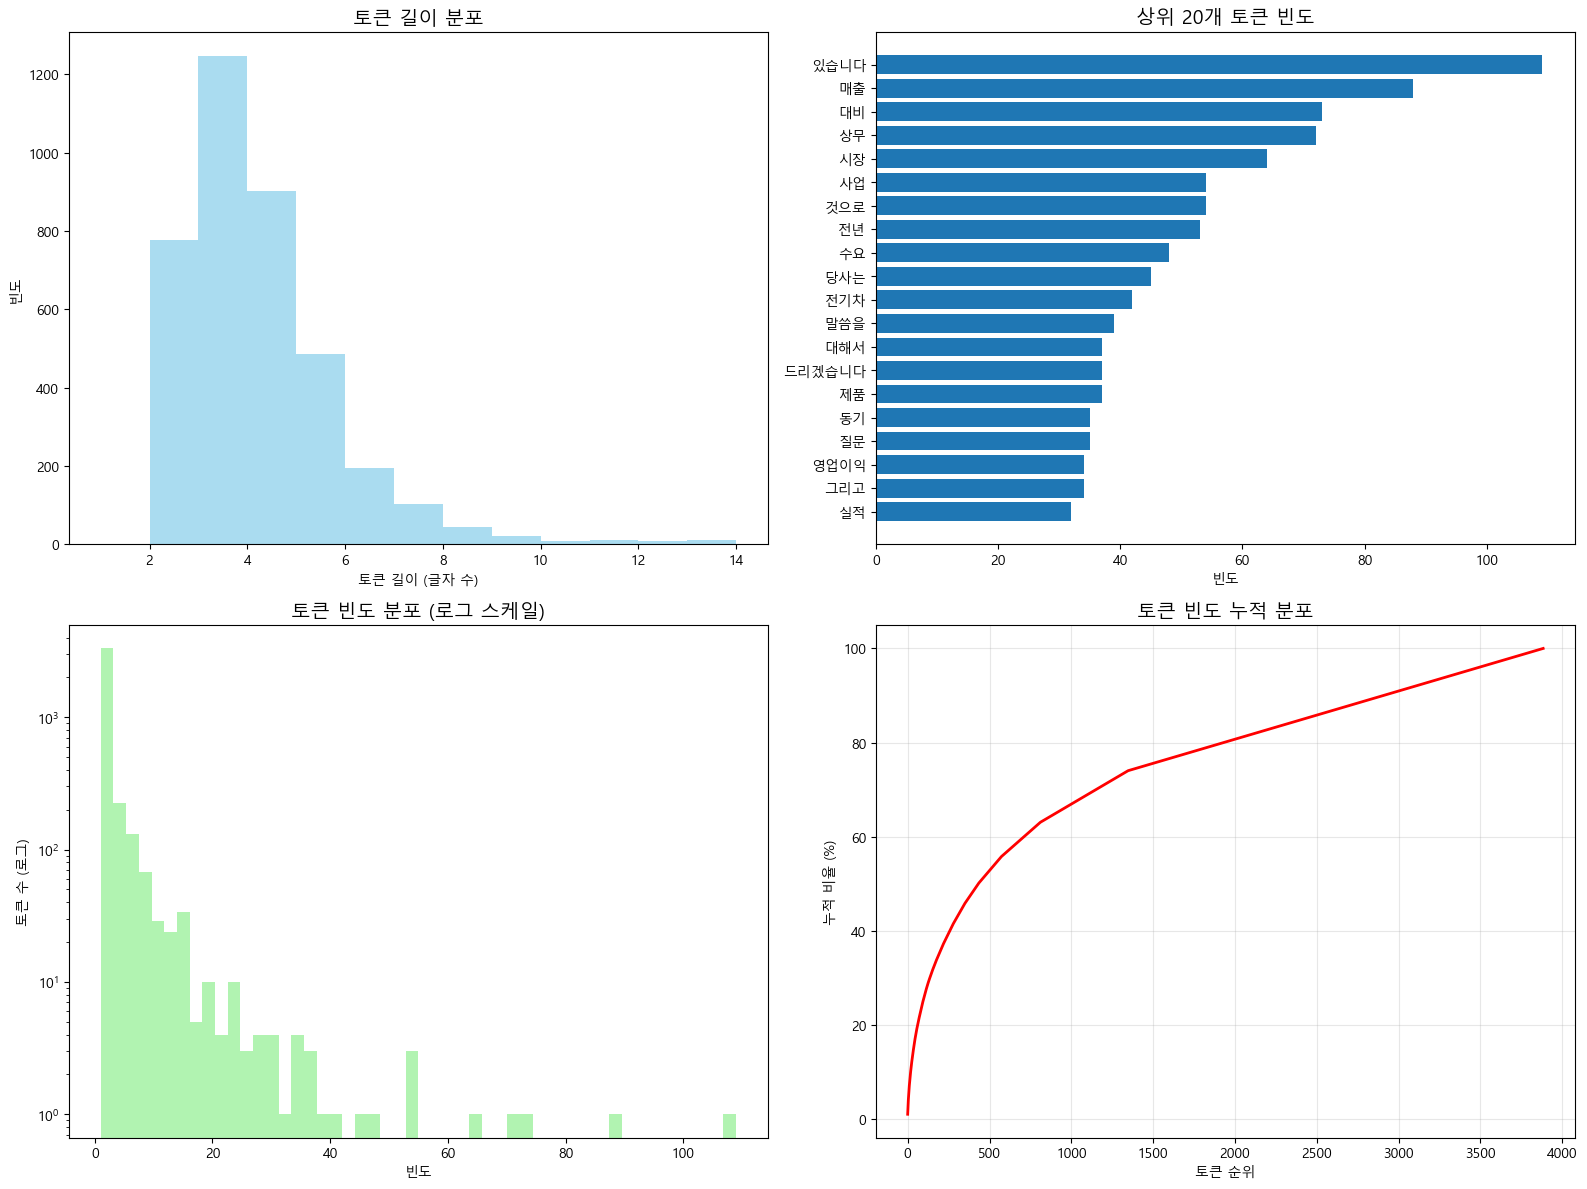


📊 토큰 통계 요약:
  평균 토큰 길이: 4.10자
  최대 토큰 길이: 72자
  최소 토큰 길이: 2자
  상위 10% 토큰이 전체 빈도의 47.8% 차지
  상위 50% 토큰이 전체 빈도의 80.1% 차지

🎉 모든 분석이 완료되었습니다!
📁 생성된 모든 파일을 확인해보세요.


In [49]:
# 추가 분석: 토큰 길이별 분포
def analyze_token_characteristics(token_df):
    """
    토큰 특성 분석 (길이, 분포 등)
    """
    print("🔍 토큰 특성 분석 중...")
    
    # 토큰 길이 분석
    token_df['token_length'] = token_df['token'].str.len()
    
    # 시각화
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. 토큰 길이 분포
    axes[0, 0].hist(token_df['token_length'], bins=range(1, 15), alpha=0.7, color='skyblue')
    axes[0, 0].set_title('토큰 길이 분포', fontsize=14)
    axes[0, 0].set_xlabel('토큰 길이 (글자 수)')
    axes[0, 0].set_ylabel('빈도')
    
    # 2. 상위 20개 토큰 빈도 막대그래프
    top_20 = token_df.head(20)
    axes[0, 1].barh(range(len(top_20)), top_20['total_frequency'])
    axes[0, 1].set_yticks(range(len(top_20)))
    axes[0, 1].set_yticklabels(top_20['token'])
    axes[0, 1].set_title('상위 20개 토큰 빈도', fontsize=14)
    axes[0, 1].set_xlabel('빈도')
    axes[0, 1].invert_yaxis()
    
    # 3. 빈도 분포 (로그 스케일)
    axes[1, 0].hist(token_df['total_frequency'], bins=50, alpha=0.7, color='lightgreen')
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_title('토큰 빈도 분포 (로그 스케일)', fontsize=14)
    axes[1, 0].set_xlabel('빈도')
    axes[1, 0].set_ylabel('토큰 수 (로그)')
    
    # 4. 누적 분포
    cumulative_pct = (token_df['total_frequency'].cumsum() / token_df['total_frequency'].sum() * 100)
    axes[1, 1].plot(range(len(cumulative_pct)), cumulative_pct, color='red', linewidth=2)
    axes[1, 1].set_title('토큰 빈도 누적 분포', fontsize=14)
    axes[1, 1].set_xlabel('토큰 순위')
    axes[1, 1].set_ylabel('누적 비율 (%)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('lg_electronics_token_characteristics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 통계 요약
    print("\n📊 토큰 통계 요약:")
    print(f"  평균 토큰 길이: {token_df['token_length'].mean():.2f}자")
    print(f"  최대 토큰 길이: {token_df['token_length'].max()}자")
    print(f"  최소 토큰 길이: {token_df['token_length'].min()}자")
    print(f"  상위 10% 토큰이 전체 빈도의 {cumulative_pct.iloc[len(cumulative_pct)//10]:.1f}% 차지")
    print(f"  상위 50% 토큰이 전체 빈도의 {cumulative_pct.iloc[len(cumulative_pct)//2]:.1f}% 차지")

# 토큰 특성 분석 실행
analyze_token_characteristics(token_df)

print("\n🎉 모든 분석이 완료되었습니다!")
print("📁 생성된 모든 파일을 확인해보세요.")